# Task 1: Diagnostic Enhancement of Chest X-Rays

**Goal:** Take severely underexposed chest X-rays and mathematically process them
so lung cavities and fluid build-up become visible, before handing them to
diagnostic doctors.

Pipeline: Load -> Histogram Equalization -> Color Mapping -> Color Balance ->
Thresholding -> Log Transform -> Gamma (Power-Law) Transform.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

def show(img, title, cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


## 1. Load and Display
Load the raw, underexposed grayscale X-ray.

Shape: (232, 232) | dtype: uint8 | min/max: 0 255


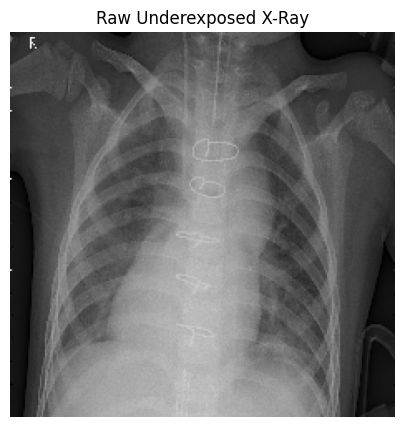

True

In [2]:
raw = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)
print('Shape:', raw.shape, '| dtype:', raw.dtype, '| min/max:', raw.min(), raw.max())
show(raw, 'Raw Underexposed X-Ray')
cv2.imwrite('output/01_raw.png', raw)


## 2. Contrast Enhancement (Histogram Equalization)
Forcefully redistributes pixel intensities across the full 0-255 range so
lung structures that were compressed into a narrow dark band become visible.

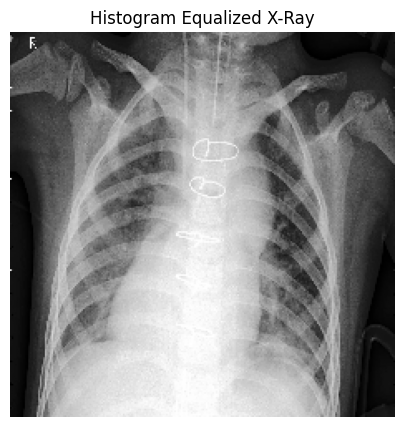

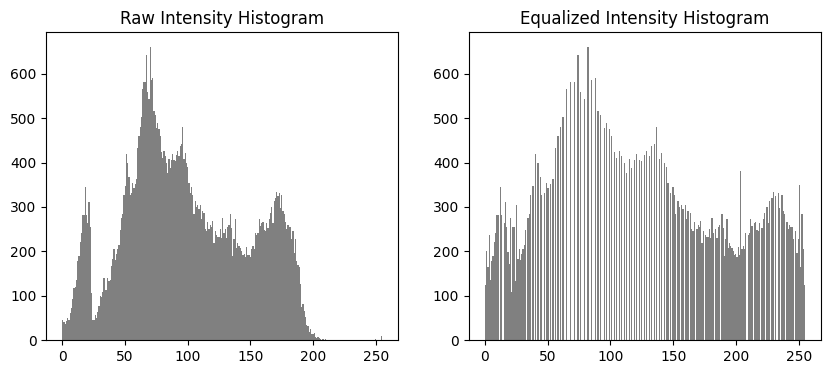

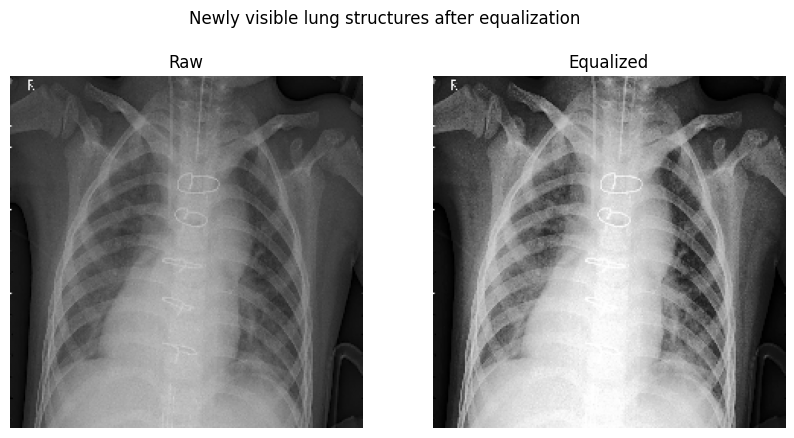

In [3]:
equalized = cv2.equalizeHist(raw)
show(equalized, 'Histogram Equalized X-Ray')
cv2.imwrite('output/02_equalized.png', equalized)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(raw.ravel(), bins=256, range=(0, 255), color='gray')
ax[0].set_title('Raw Intensity Histogram')
ax[1].hist(equalized.ravel(), bins=256, range=(0, 255), color='gray')
ax[1].set_title('Equalized Intensity Histogram')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(raw, cmap='gray'); ax[0].set_title('Raw'); ax[0].axis('off')
ax[1].imshow(equalized, cmap='gray'); ax[1].set_title('Equalized'); ax[1].axis('off')
plt.suptitle('Newly visible lung structures after equalization')
plt.show()


**Observation:** the raw histogram is crushed into a narrow low-intensity
band (severe underexposure). After equalization the histogram spreads across
the full range, and the rib boundaries / lung field edges that were
invisible in the raw image become distinguishable.

## 3. Color Mapping
Convert the equalized grayscale image into a false-color heatmap
(`COLORMAP_JET`). Mapping intensity to a color spectrum helps the human eye
pick up subtle fluid boundaries that are hard to see in pure grayscale.

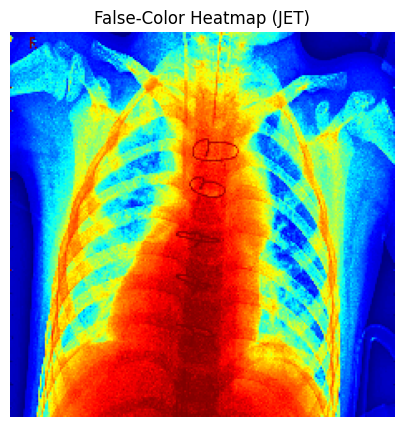

True

In [4]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)
show(heatmap, 'False-Color Heatmap (JET)')
cv2.imwrite('output/03_heatmap.png', heatmap)


## 4. Color Balance
Simulate a lighting correction: shift each channel so the mean is
neutralized, removing artificial color casts introduced by the colormap.

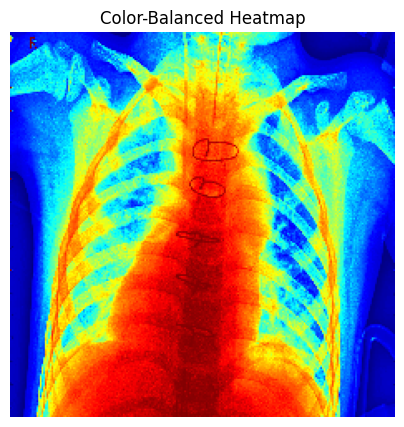

True

In [5]:
def color_balance(img):
    result = img.copy().astype(np.float32)
    for c in range(3):
        mean = result[:, :, c].mean()
        # push each channel mean toward the overall gray mean (128)
        result[:, :, c] += (128 - mean) * 0.3
    return np.clip(result, 0, 255).astype(np.uint8)

balanced = color_balance(heatmap)
show(balanced, 'Color-Balanced Heatmap')
cv2.imwrite('output/04_color_balanced.png', balanced)


## 5. Color Filtering (Thresholding)
Dense tissue (bone / dense fluid) reflects high-intensity values. Apply a
strict binary threshold to mask out everything except the densest tissue.

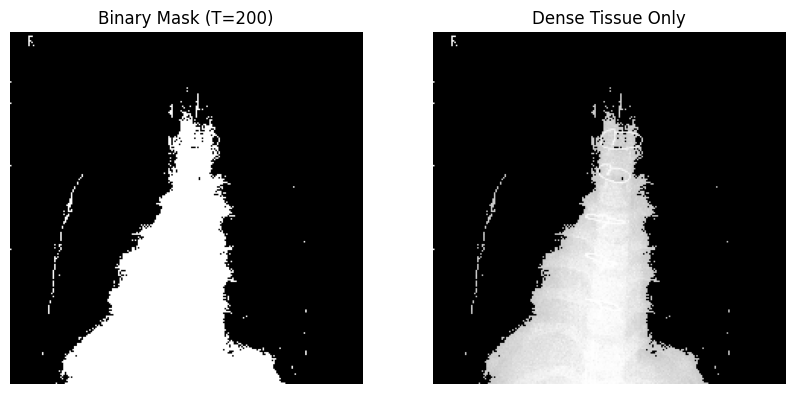

True

In [6]:
THRESH = 200  # tune based on your dataset's dense-tissue intensity
_, dense_mask = cv2.threshold(equalized, THRESH, 255, cv2.THRESH_BINARY)
dense_tissue_only = cv2.bitwise_and(equalized, equalized, mask=dense_mask)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(dense_mask, cmap='gray'); ax[0].set_title(f'Binary Mask (T={THRESH})'); ax[0].axis('off')
ax[1].imshow(dense_tissue_only, cmap='gray'); ax[1].set_title('Dense Tissue Only'); ax[1].axis('off')
plt.show()
cv2.imwrite('output/05_dense_mask.png', dense_mask)
cv2.imwrite('output/05_dense_tissue_only.png', dense_tissue_only)


## 6. Logarithmic Transformation
Applied to the *raw* underexposed image. Expands the dark background
regions to reveal faint outer edges of the ribcage that are otherwise lost
near zero intensity.

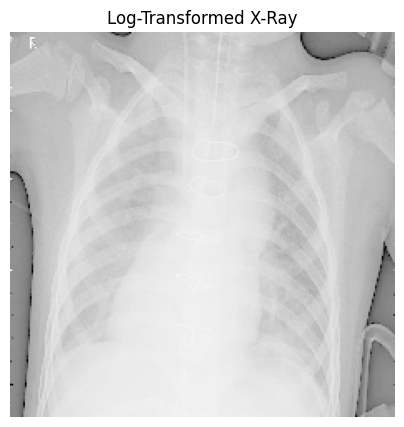

True

In [7]:
raw_f = raw.astype(np.float32)
c = 255 / np.log(1 + raw_f.max())
log_transformed = c * np.log(1 + raw_f)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

show(log_transformed, 'Log-Transformed X-Ray')
cv2.imwrite('output/06_log_transformed.png', log_transformed)


## 7. Power-Law (Gamma) Transformation
Apply a fractional gamma (< 1.0) to compress the harsh contrast of bright
bone regions, so mid-tone soft-tissue detail becomes clearer without
blowing out highlights.

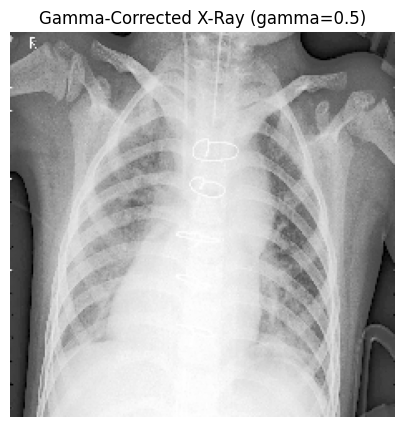

True

In [8]:
GAMMA = 0.5  # gamma < 1.0 brightens midtones / compresses highlight contrast
norm = equalized.astype(np.float32) / 255.0
gamma_corrected = np.power(norm, GAMMA) * 255.0
gamma_corrected = np.clip(gamma_corrected, 0, 255).astype(np.uint8)

show(gamma_corrected, f'Gamma-Corrected X-Ray (gamma={GAMMA})')
cv2.imwrite('output/07_gamma_corrected.png', gamma_corrected)


## 8. Final Comparison

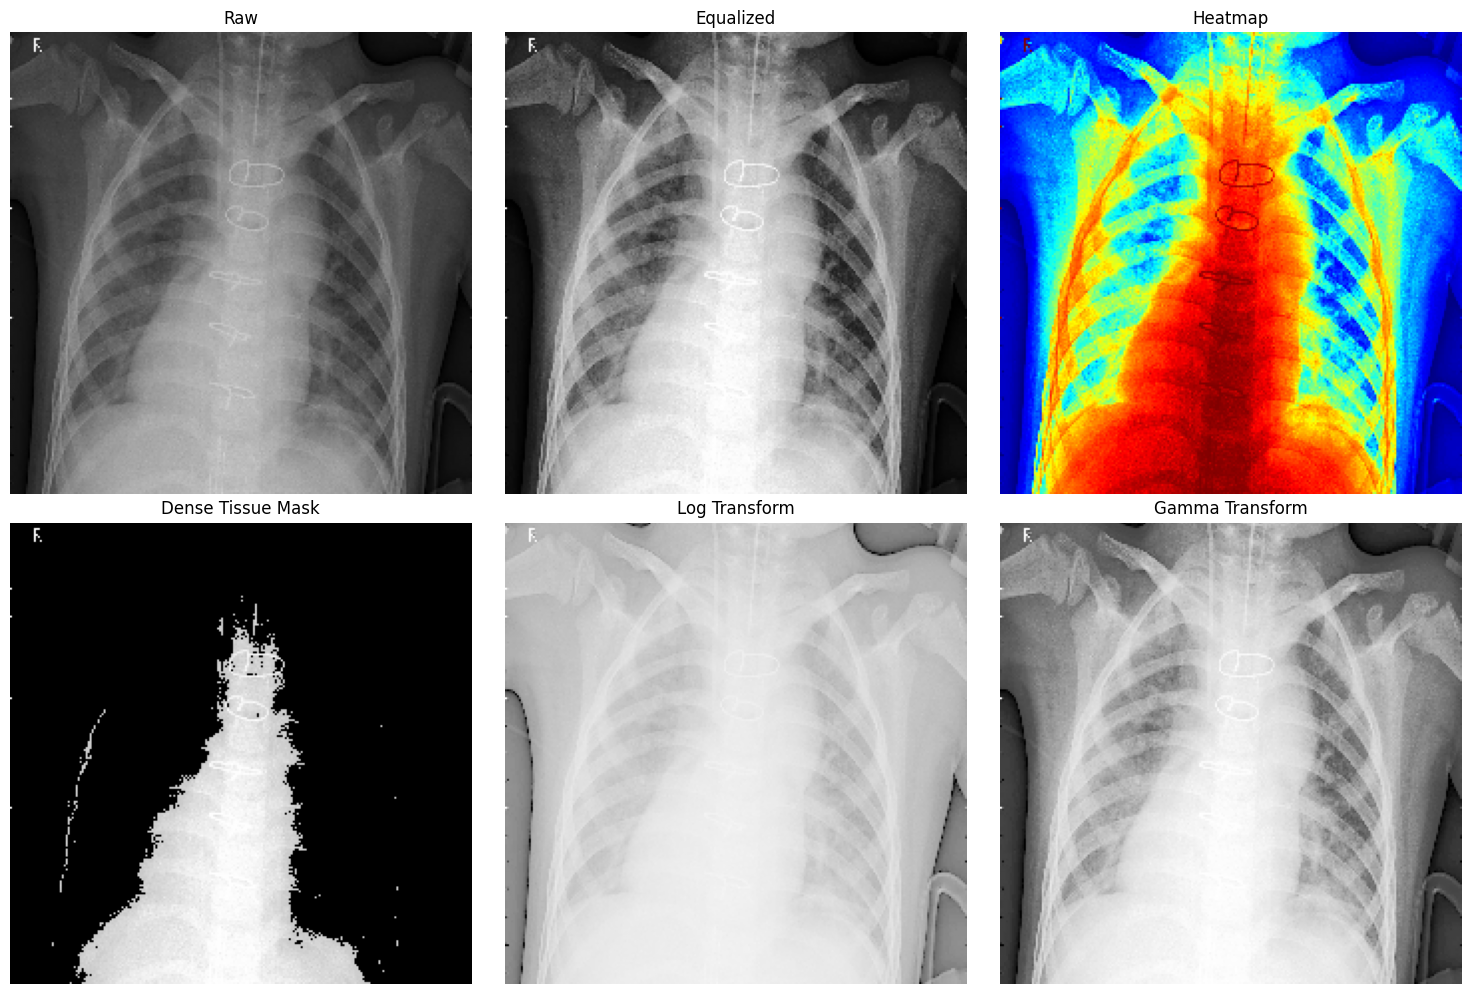

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
imgs = [raw, equalized, cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB),
        dense_tissue_only, log_transformed, gamma_corrected]
titles = ['Raw', 'Equalized', 'Heatmap', 'Dense Tissue Mask', 'Log Transform', 'Gamma Transform']
for a, im, t in zip(ax.ravel(), imgs, titles):
    a.imshow(im, cmap='gray' if im.ndim == 2 else None)
    a.set_title(t)
    a.axis('off')
plt.tight_layout()
plt.savefig('output/08_final_comparison.png', dpi=150)
plt.show()
